In [51]:
import numpy as np
import matplotlib.pyplot as plt

# Affine arithmetic library
import affapy as af
from affapy.aa import Affine
from affapy.ia import Interval

CASE 1: All independent uncertainties

In [52]:
def beam_deflection(P, L, E, I, x):

    # deflection = P * L**3 / (3 * E * I)
    deflection = (P * x**2 * (3*L - x)) / (6 * E * I)

    return deflection

In [53]:
# Set a percentage to define each interval
percentage = 0.10

P_midpoint = 500 # [N]
P_lower, P_upper = P_midpoint*(1-percentage), P_midpoint*(1+percentage)
P_radius = (P_upper-P_lower)/2
P = Interval(P_lower, P_upper)

E_midpoint = 210e9 # [Pa]
E_lower, E_upper = E_midpoint*(1-percentage), E_midpoint*(1+percentage)
E_radius = (E_upper-E_lower)/2
E = Interval(E_lower, E_upper)

L_midpoint = 2 # [m]
L_lower, L_upper = L_midpoint*(1-percentage), L_midpoint*(1+percentage)
L_radius = (L_upper-L_lower)/2
L = Interval(L_lower, L_upper)

# b_midpoint = 0.1 # [m]
# b_lower, b_upper = b_midpoint*(1-percentage), b_midpoint*(1+percentage)
# b_radius = (b_upper-b_lower)/2
# B = Interval(b_lower, b_upper)

# h_midpoint = 0.04 # [m]
# h_lower, h_upper = h_midpoint*(1-percentage), h_midpoint*(1+percentage)
# h_radius = (h_upper-h_lower)/2
# H = Interval(h_lower, h_upper)

i_midpoint = 9e-8 # [m4]
i_lower, i_upper = i_midpoint*(1-percentage), i_midpoint*(1+percentage)
i_radius = (i_upper-i_lower)/2
I = Interval(i_lower, i_upper)

# Compute deflection using traditional interval arithemetic
IA_deflection = beam_deflection(P, L, E, I, 2)
print(IA_deflection)


[0.0446018627836809, 0.110174842685131]


In [55]:
# Convert to affine arithmetic, we will use lower case symbols instead
p = Affine(x0=P_midpoint, xi={1:(P_radius)})
e = Affine(x0=E_midpoint, xi={2:(E_radius)})
l = Affine(x0=L_midpoint, xi={3:(L_radius)})
# b = Affine(x0=b_midpoint, xi={4:(b_radius)})
# h = Affine(x0=h_midpoint, xi={5:(h_radius)})
i = Affine(x0=i_midpoint, xi={4:(i_radius)})

print(p)
print(e)
print(l)
# print(b)
# print(h)
print(i)
AA_deflection = beam_deflection(p, l, e, i, 2) 
print(AA_deflection)
print(AA_deflection.interval)


500.0 + 50.0e1
210000000000.0 + 21000000000.0e2
2.0 + 0.2e3
9.0e-8 + 9.00000000000001e-9e4
0.073801377982429 + 0.0073801377982429e1 + -0.00481843707488586e2 + 0.0110702066973644e3 + -0.00481843707488586e4 + 0.00110702066973644e410 + -0.000481843707488587e411 + 0.00537957151904979e412 + 0.00410704668472218e413
[0.034638676756053, 0.112964079208805]


In [48]:
# Lets assign the same uncertainty source (i.e. e1 for all variables)
p = Affine(x0=P_midpoint, xi={1:(P_radius)})
e = Affine(x0=E_midpoint, xi={1:(E_radius)})
l = Affine(x0=L_midpoint, xi={1:(L_radius)})
# b = Affine(x0=b_midpoint, xi={1:(b_radius)})
# h = Affine(x0=h_midpoint, xi={1:(h_radius)})
i = Affine(x0=i_midpoint, xi={1:(i_radius)})

print(p)
print(e)
print(l)
# print(b)
# print(h)
print(i)

AA_deflection_shared = beam_deflection(p, l, e, i, 2) 
print(AA_deflection_shared)
print(AA_deflection_shared.interval)


500.0 + 50.0e1
210000000000.0 + 21000000000.0e1
2.0 + 0.2e1
9.0e-8 + 9.00000000000001e-9e1
0.073801377982429 + 0.00881347034583553e1 + 0.00110702066973644e382 + -0.000481843707488587e383 + 0.00537957151904979e384 + 0.00410704668472218e385
[0.0539124250555965, 0.0936903309092615]


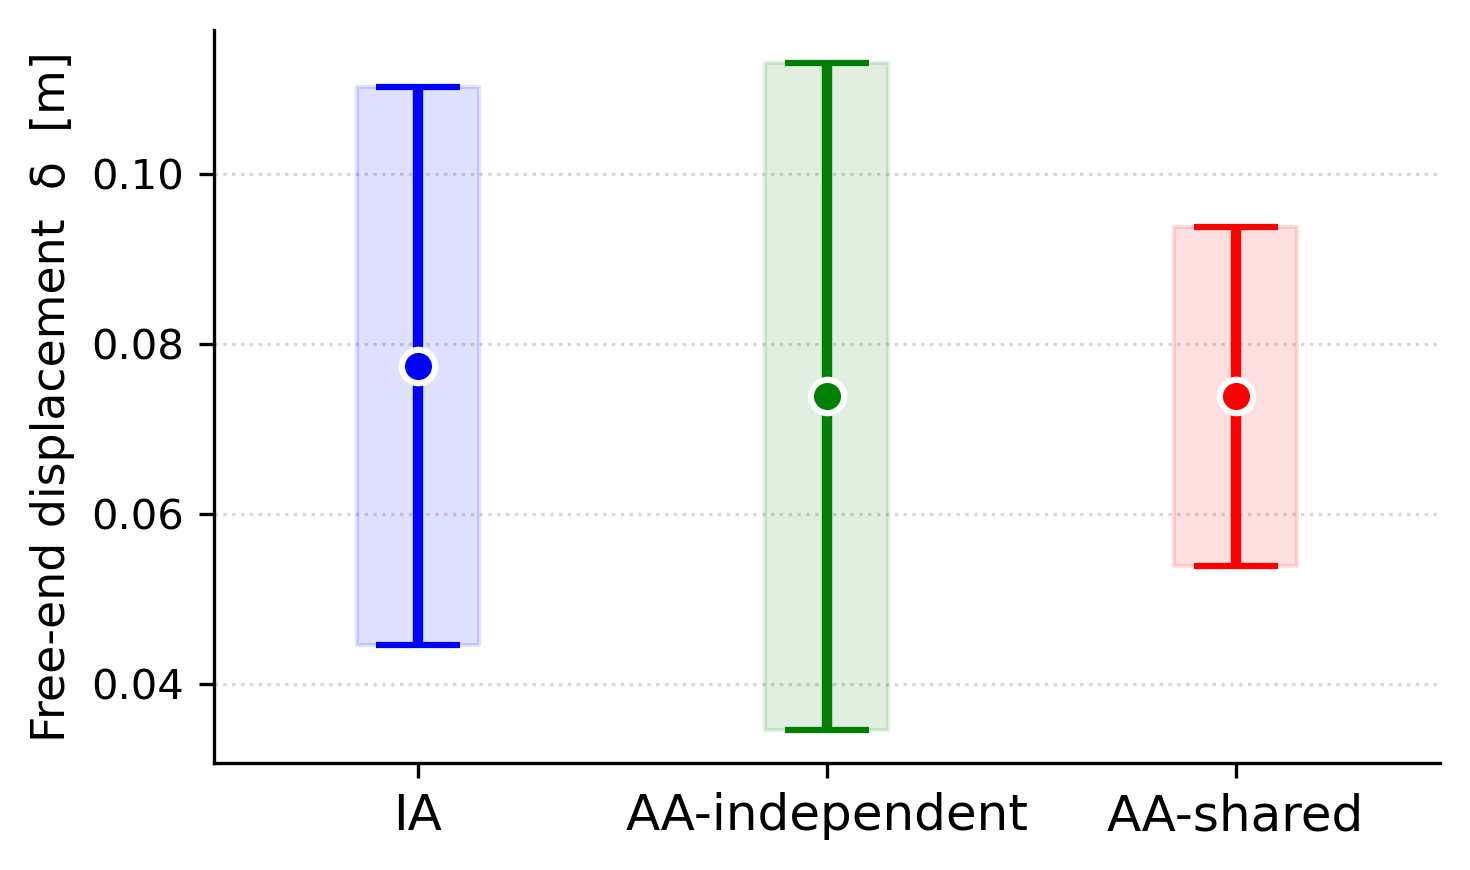

In [49]:
labels  = ["IA", "AA-independent", "AA-shared"]
centers = [float(IA_deflection.mid()),       float(AA_deflection.x0),  float(AA_deflection_shared.x0)]
errors  = [float(IA_deflection.radius()),       float(AA_deflection.rad()),  float(AA_deflection_shared.rad())]

x = np.arange(len(labels))

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 3), dpi=300)

colors      = ["blue", "green", "red"]
cap_size    = 10
marker_size = 8

for i, (xi, ci, ei, color) in enumerate(zip(x, centers, errors, colors)):
    ax.errorbar(
        xi, ci, yerr=ei,
        fmt="o",
        color=color,
        ecolor=color,
        elinewidth=2.5,
        capsize=cap_size,
        capthick=2.5,
        markersize=marker_size,
        markeredgewidth=1.5,
        markeredgecolor="white",
        label=f"{labels[i]}:  [{ci-ei:.4f}, {ci+ei:.4f}]  (width = {2*ei:.4f})",
        zorder=3,
    )

# Shaded interval bands for visual comparison
for i, (xi, ci, ei, color) in enumerate(zip(x, centers, errors, colors)):
    ax.fill_between([xi - 0.15, xi + 0.15], ci - ei, ci + ei,
                    color=color, alpha=0.12, zorder=2)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylabel("Free-end displacement  δ  [m]", fontsize=11)

# ax.legend(fontsize=8, loc="lower right", framealpha=0.9)
ax.set_xlim(-0.5, len(labels) - 0.5)
ax.grid(axis="y", linestyle=":", alpha=0.5)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

In [50]:
"""
Cantilever Tip Deflection: Interval vs Affine Arithmetic
=========================================================
Formula (at x = L):  d = P·L³ / (3·E·I)

Compares the enclosure width produced by:
  - Interval Arithmetic (IA)  — affapy.ia
  - Affine Arithmetic   (AA)  — affapy.aa
"""

import affapy.aa as aa
import affapy.ia as ia

# ── Parameters ────────────────────────────────────────────────────
P_m, L_m, E_m, I_m = 500.0, 2.0, 210e9, 9e-8   # midpoint values
f = 0.10                                           # ±10% half-width
 
d_exact = P_m * L_m**3 / (3 * E_m * I_m)
 
# ── 1. Interval Arithmetic (independent) ──────────────────────────
P_i = ia.Interval(P_m*(1-f), P_m*(1+f))
L_i = ia.Interval(L_m*(1-f), L_m*(1+f))
E_i = ia.Interval(E_m*(1-f), E_m*(1+f))
I_i = ia.Interval(I_m*(1-f), I_m*(1+f))
 
d_ia = (P_i * L_i**3) / (ia.Interval(3, 3) * E_i * I_i)
 
# ── 2. Affine Arithmetic (independent unique symbols) ──────────────
# aa.Affine([lo, hi]) assigns a fresh noise symbol to each variable
P_a = aa.Affine([P_m*(1-f), P_m*(1+f)])
L_a = aa.Affine([L_m*(1-f), L_m*(1+f)])
E_a = aa.Affine([E_m*(1-f), E_m*(1+f)])
I_a = aa.Affine([I_m*(1-f), I_m*(1+f)])
 
d_aa_indep = (P_a * L_a * L_a * L_a) / (aa.Affine([3, 3]) * E_a * I_a)
 
# ── 3. Affine Arithmetic (shared noise symbol ε₁) ──────────────────
# Construct affine forms manually so all four share noise symbol key=1.
# This models perfect positive correlation: all parameters deviate by
# the same fraction simultaneously.
#
#   x = x_mid + x_mid·f · ε₁
#
P_s = aa.Affine(x0=P_m, xi={1: P_m * f})
L_s = aa.Affine(x0=L_m, xi={1: L_m * f})
E_s = aa.Affine(x0=E_m, xi={1: E_m * f})
I_s = aa.Affine(x0=I_m, xi={1: I_m * f})
 
d_aa_shared = (P_s * L_s * L_s * L_s) / (aa.Affine([3, 3]) * E_s * I_s)
 
# ── 4. Analytical exact result for shared-symbol case ──────────────
# Substituting x = mid*(1 + f*ε) for each parameter:
#
#   d(ε) = P·(1+fε) · [L·(1+fε)]³ / [3 · E·(1+fε) · I·(1+fε)]
#        = d_exact · (1+fε)⁴ / (1+fε)²
#        = d_exact · (1+fε)²
#
# For ε ∈ [−1, 1] the range is:
#   d ∈ [d_exact·(1−f)², d_exact·(1+f)²]
#
true_lo = d_exact * (1 - f)**2
true_hi = d_exact * (1 + f)**2
true_w  = true_hi - true_lo
 
# ── Results ─────────────────────────────────────────────────────────
ia_lo, ia_hi, ia_w = float(d_ia.inf), float(d_ia.sup), float(d_ia.width())
aa_i_lo  = float(d_aa_indep.interval.inf)
aa_i_hi  = float(d_aa_indep.interval.sup)
aa_i_w   = float(d_aa_indep.interval.width())
aa_s_lo  = float(d_aa_shared.interval.inf)
aa_s_hi  = float(d_aa_shared.interval.sup)
aa_s_w   = float(d_aa_shared.interval.width())
 
print("=" * 70)
print("  Cantilever Tip Deflection — Noise Symbol Correlation Comparison")
print("  d = P·L³ / (3·E·I)   at x = L,   ±5% on all parameters")
print("=" * 70)
print(f"\n  Exact midpoint  d = {d_exact:.6e} m\n")
 
rows = [
    ("IA  (independent params)",    ia_lo,   ia_hi,   ia_w),
    ("AA  (independent symbols)",   aa_i_lo, aa_i_hi, aa_i_w),
    ("AA  (shared symbol ε₁)",      aa_s_lo, aa_s_hi, aa_s_w),
    ("Exact (shared, analytical)",  true_lo, true_hi, true_w),
]
 
print(f"  {'Method':<28} {'Lower':>12} {'Upper':>12} {'Width':>12}")
print("  " + "-" * 68)
for name, lo, hi, w in rows:
    print(f"  {name:<28} {lo:>12.6e} {hi:>12.6e} {w:>12.6e}")
 
print(f"""
  Analytical derivation — shared symbol case
  ───────────────────────────────────────────
  With all params = mid·(1 + f·ε), ε ∈ [−1, +1]:
 
    d(ε) = d_exact · (1+f·ε)⁴ / (1+f·ε)²  =  d_exact · (1+f·ε)²
 
    True range: [{true_lo:.6e}, {true_hi:.6e}]
    Width:       {true_w:.6e} m
 
  The numerator grows as (1+f·ε)⁴ (one power from P, three from L³)
  while the denominator grows as (1+f·ε)² (one from E, one from I),
  so cancellation is only partial — d still varies, proportional to
  (1+f·ε)².  If the denominator had four matching powers, d would be
  constant and the width would collapse to zero.
 
  AA (shared) overestimates the true width by {(aa_s_w/true_w - 1)*100:.0f}% due to
  linearisation error when multiplying affine forms (each nonlinear
  product introduces a fresh independent error term).
 
  Width summary (ascending):
    Exact (shared)   {true_w:.6e} m  ← true range under perfect correlation
    AA shared        {aa_s_w:.6e} m  ← ~{aa_s_w/true_w:.1f}× exact
    IA independent   {ia_w:.6e} m  ← ~{ia_w/true_w:.1f}× exact
    AA independent   {aa_i_w:.6e} m  ← ~{aa_i_w/true_w:.1f}× exact
 
  Shared-symbol AA is {ia_w/aa_s_w:.1f}× tighter than independent IA,
  and {aa_i_w/aa_s_w:.1f}× tighter than independent AA.
""")

  Cantilever Tip Deflection — Noise Symbol Correlation Comparison
  d = P·L³ / (3·E·I)   at x = L,   ±5% on all parameters

  Exact midpoint  d = 7.054674e-02 m

  Method                              Lower        Upper        Width
  --------------------------------------------------------------------
  IA  (independent params)     3.825266e-02 1.275154e-01 8.926275e-02
  AA  (independent symbols)    1.685911e-02 1.307436e-01 1.138845e-01
  AA  (shared symbol ε₁)       3.613286e-02 1.114699e-01 7.533703e-02
  Exact (shared, analytical)   5.714286e-02 8.536155e-02 2.821869e-02

  Analytical derivation — shared symbol case
  ───────────────────────────────────────────
  With all params = mid·(1 + f·ε), ε ∈ [−1, +1]:
 
    d(ε) = d_exact · (1+f·ε)⁴ / (1+f·ε)²  =  d_exact · (1+f·ε)²
 
    True range: [5.714286e-02, 8.536155e-02]
    Width:       2.821869e-02 m
 
  The numerator grows as (1+f·ε)⁴ (one power from P, three from L³)
  while the denominator grows as (1+f·ε)² (one from E, one fr